In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [4]:
from ranking import Ranking, FRACTIONAL
def MannWhitneyU_myZ(Sample1,Sample2):        
    NewSample = np.concatenate((Sample1,Sample2),axis=0)
    NewRanks, Groups = get_fract_ranks_and_groups(NewSample)
    SumRanks = 0
    SumRanks2 = 0
    for i in range(Sample1.shape[0]):
        SumRanks += NewRanks[i]
        SumRanks2 += NewRanks[Sample1.shape[0]+i]
    U1 = SumRanks - Sample1.shape[0]*(Sample1.shape[0]+1.0)/2.0
    U2 = SumRanks2 - Sample2.shape[0]*(Sample2.shape[0]+1.0)/2.0
    Umean = Sample1.shape[0]*Sample2.shape[0]/2.0
    GroupsSum = 0
    for index in Groups:
        GroupsSum += (index*index*index - index)/12
    N = Sample1.shape[0]+Sample2.shape[0]
    part1 = Sample1.shape[0]*Sample2.shape[0]/(N*(N-1.0))
    part2 = (N*N*N-N)/12.0
    Ucorr2 = math.sqrt(part1*(part2-GroupsSum))
    if(Ucorr2 != 0):
        Z1 = (U1 - Umean)/Ucorr2
        Z2 = (U2 - Umean)/Ucorr2
    else:
        return (0,0)
    if(Z1 <= Z2):
        if(Z1 < -2.58):
            return (-1, Z1)
    else:
        if(Z2 < -2.58):   
            return (1, Z1)
    return (0, Z1)
def ranks(ranking):
    return list(ranking.ranks())   
def get_fract_ranks(data):
    sort_index = np.argsort(-data)
    sort_list = -np.sort(-data)
    new_ranks = ranks(Ranking(sort_list, FRACTIONAL))
    index_rank = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        new_rank_inv = data.shape[0] - new_ranks[i] - 1
        index_rank[sort_index[i]] = new_rank_inv
    return index_rank
def FriedmanSTestNoFunc(ResultsFunction, size, NRuns):
    rankarray = np.zeros((NRuns,size))    
    for i in range(NRuns):
        rankarray[i] = get_fract_ranks(np.transpose(ResultsFunction[:,i]))
    sumranks = np.zeros(size)
    avgranks = np.zeros(size)
    for i in range(size):
        sumranks[i] = np.sum(rankarray[:,i])
    avgranks = sumranks / NRuns
    raverage = (size+1)/2.0
    FriedmanS = 0
    for i in range(size):
        FriedmanS += (avgranks[i] - raverage)*(avgranks[i] - raverage)
    FriedmanS *= 12*NRuns/(size*(size+1.))
    #print(FriedmanS)
    return avgranks
def get_fract_ranks_and_groups(data):
    sort_index = np.argsort(-data)
    sort_list = -np.sort(-data)
    groups = []
    my_new_ranks = np.zeros(data.shape[0])
    counter = 0
    while(True):
        if(counter == data.shape[0]):
            break
        if(counter == data.shape[0]-1):
            my_new_ranks[counter] = counter
            break
        if(sort_list[counter] != sort_list[counter+1]):
            my_new_ranks[counter] = counter
            counter+=1            
        else:
            avgrank = 0
            start = counter
            while(sort_list[start] == sort_list[counter]):
                avgrank += counter
                counter+=1                
                if(counter == data.shape[0]):
                    break
            avgrank = avgrank / (counter - start)
            groups.append(counter - start)
            for i in range(start,counter):
                my_new_ranks[i] = avgrank
    index_rank = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        new_rank_inv = data.shape[0] - my_new_ranks[i]
        index_rank[sort_index[i]] = new_rank_inv   
    return index_rank, groups
def FriedmanSTest(ResultsFunction, func_num, size, NRuns):
    rankarray = np.zeros((NRuns,size))    
    for i in range(NRuns):
        rankarray[i] = get_fract_ranks(np.transpose(ResultsFunction[:,i,func_num]))
    sumranks = np.zeros(size)
    avgranks = np.zeros(size)
    for i in range(size):
        sumranks[i] = np.sum(rankarray[:,i])
    avgranks = sumranks / NRuns
    raverage = (size+1)/2.0
    FriedmanS = 0
    for i in range(size):
        FriedmanS += (avgranks[i] - raverage)*(avgranks[i] - raverage)
    FriedmanS *= 12*NRuns/(size*(size+1.))
    #print(FriedmanS)
    return avgranks
colors_s = [(0.0, 0.0, 0.0),(0.9, 0.0, 0.0),(0.0, 0.9, 0.0),(0.0, 0.0, 0.9),(0.9, 0.9, 0.0),(0.9, 0.0, 0.9),(0.0, 0.9, 0.9),(0.5, 0.5, 0.0),(0.0, 0.5, 0.5)]
markers = ['o','v','^','*','d','s','+','x','P']

In [7]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

F1Test 13
(725,)
(725,)
(725,)
(725,)
(725,)
(725,)
(725,)
(725,)
(725,)
(725,)
[4.33241379 4.12896552 3.95034483 4.09517241 4.1337931  4.87724138
 5.15862069 4.99517241 5.4262069  3.90206897]
[9 2 3 1 4 0 5 7 6 8]
3.9020689655172416
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
0.0 0.0 0.0 0.0
0.202619518340159 0 0 0 2 25 2 -6.79219427889256 1 1 1 2 10 2 4.62359881833207 0 2 2 1 0 3 -3.11367919595766 0 2 3 0 3 2 -6.32075816823873 0 1 4 2 25 2 1.85124900801744 1 2 5 2 13 1 -17.3338338619406 0 2 6 0 16 1 -3.56726051706619 0 2 7 0 12 
b'rand(pow((4.62359881833207),(x[0])),rand(sqrt((x[0])),(x[0])))\n'


/tmp/ipykernel_399421/1500455070.py:73: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[f1iter].scatter(srs,res,label=r"$\frac{NFE}{NFE_{max}}=$"+fr"${NFER:.2f}$",c=colors_s[(i)%len(colors_s)],s=4)


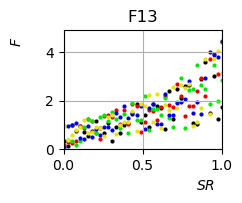

In [63]:
#functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
#functotest = [3,4,7,9,12,13,16,17,20,21,24,25,28,29]
#functotest = [5,6,10,11,14,15,18,19,22,23,26,27]
functotest = [13]
fig = plt.figure(figsize=(5, 15))
gs = gridspec.GridSpec(7,2)
gs.update(wspace=0.45, hspace=0.45) # set the spacing between axes. 
ax = []
for i in range(len(functotest)):
    ax.append(plt.subplot(gs[i]))
for f1iter,F1Test in enumerate(functotest):
    print("F1Test",F1Test)
    path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC/"
    NExp = 10
    NFunc = 29
    NRuns = 25
    NTests = NFunc*NRuns
    AllData = np.zeros((NExp,NTests))
    AllEq = []
    for run in range(NExp):
        filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_R{run}.txt"
        #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
        Xdata = np.loadtxt(filename)
        #print(Xdata.shape)
        #AllData[run] = Xdata[-1,:]
        AllData[run] = Xdata
        filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
        with open(filename_eq) as f:
            eq1 = f.readlines()
        AllEq.append(eq1[-1])
    srs = np.linspace(0,1,40)
    
    ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
    print(ranks1)
    sorted_index1 = np.argsort(ranks1)
    print(sorted_index1)
    chosen = sorted_index1[0]
    print(ranks1[chosen])
    tree = AllEq[chosen]
    cur_res = AllData[chosen][(F1Test-1):NFunc*NRuns:NFunc]
    print(cur_res)
    print(np.min(cur_res),
          np.median(cur_res),
          np.mean(cur_res),
          np.max(cur_res))
    print(tree[:-3])
    print(get_tree_eq(tree[:-3]))
    #print("F = min(max(res,-10.0),10.0);")
    
    N123 = 5
    '''allres = []
    for i in range(N123):
        for j in range(1):
            res = [get_tree_res(tree[:-3],1.0/(N123-1)*i,x) for x in srs]
            SRV = 1.0/(N123-1)*i
            ax[0].plot(srs,res,label=fr"$SR={SRV:.2f}$",c=colors_s[i])              
            allres.append(np.clip(res,-10,10))
    allres = np.array(allres)            
    minres = np.min([np.min(allres),0])
    maxres = np.max([1,np.max(allres)])*1.1
    ax[0].set_ylim(minres,maxres)
    ax[0].set_xlim(0,1)
    ax[0].grid(True)
    ax[0].set_xlabel(r"$\frac{NFE}{NFE_{max}}$")
    ax[0].set_ylabel(r"$F$")
    ax[0].legend(loc='center', bbox_to_anchor=(0.95, -0.4)) '''
    
    allres = []
    for i in range(N123):
        for j in range(1):
            res = [get_tree_res(tree[:-3],x,1.0/(N123-1)*i) for x in srs]  
            NFER = 1.0/(N123-1)*i
            ax[f1iter].scatter(srs,res,label=r"$\frac{NFE}{NFE_{max}}=$"+fr"${NFER:.2f}$",c=colors_s[(i)%len(colors_s)],s=4)  
            allres.append(np.clip(res,-10,10))
    allres = np.array(allres)            
    minres = np.min([np.min(allres),0])
    maxres = np.max([1,np.max(allres)])*1.1
    ax[f1iter].set_ylim(minres,maxres)
    ax[f1iter].set_xlim(0,1)
    ax[f1iter].grid(True)
    ax[f1iter].set_xlabel(r"$SR$")
    ax[f1iter].set_ylabel(r"$F$")
    ax[f1iter].set_title(f"F{F1Test}")
    ax[f1iter].xaxis.set_label_coords(0.9, -0.25)
    ax[f1iter].yaxis.set_label_coords(-0.25, 0.9)
    
    #plt.legend(loc='upper right')    
    #break
#ax[len(functotest)-2].legend(loc='center', bbox_to_anchor=(0.5, -1.1)) 
plt.show()    
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_1"+".png",bbox_inches='tight')
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_1"+".svg",bbox_inches='tight')
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_1"+".pdf",bbox_inches='tight')

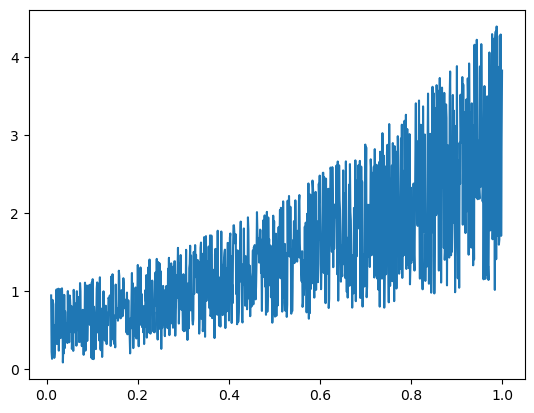

In [62]:
xvals = np.linspace(0.01,1,1000)
#print(xvals)
x = np.zeros(2)
x[1] = 1
#np.exp(((((xvals)/np.sqrt(1.0+((x[1]))*((x[1]))))>(6.14249506974866))!=(((-3.53567276865263)==(3.61211023181787))==(3.61211023181787)))),
#yvals = (-((-((1.60816924430403)/np.sqrt(1.0+(1.0/((xvals)))*(1.0/((xvals))))))-(0.399287392716864)))
yvals = np.random.uniform(np.pow((4.62359881833207),(xvals)),np.random.uniform(np.sqrt((xvals)),(xvals)))
#yvals2 = 1.60816924430403 / np.sqrt(1 + 1/(xvals*xvals)) + 0.399287392716864
#yvals2 = 1.60816924430403 * xvals + 0.399287392716864
#for i in range(len(yvals)):
    #if(yvals[i] > 1):
    #    yvals[i] = 1
    #if(yvals2[i] > 1):
    #    yvals2[i] = 1
plt.plot(xvals,yvals)
#plt.plot(xvals,yvals2)
#plt.ylim(0,1.1)

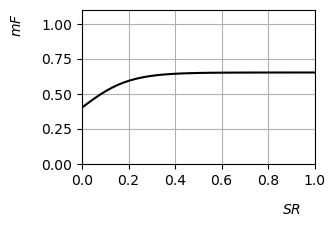

In [12]:
fig = plt.figure(figsize=(3, 2))
ax = plt.subplot()
#gs = gridspec.GridSpec(1,1)
#gs.update(wspace=0.45, hspace=0.45) # set the spacing between axes. 
#ax = []
#for i in range(1):
#    ax.append(plt.subplot(gs[i]))
allres = []
f1iter = 0
for i in range(1):
    for j in range(1):
        res = [0.4+0.25*np.tanh(x*5) for x in srs]  
        NFER = 1.0/(N123-1)*i
        ax.plot(srs,res,label=r"$\frac{NFE}{NFE_{max}}=$"+fr"${NFER:.2f}$",c=colors_s[(i)%len(colors_s)])  
        allres.append(np.clip(res,-10,10))
allres = np.array(allres)            
minres = np.min([np.min(allres),0])
maxres = np.max([1,np.max(allres)])*1.1
ax.set_ylim(minres,maxres)
ax.set_xlim(0,1)
ax.grid(True)
ax.set_xlabel(r"$SR$")
ax.set_ylabel(r"$mF$")
#ax[f1iter].set_title(f"F{F1Test}")
ax.xaxis.set_label_coords(0.9, -0.25)
ax.yaxis.set_label_coords(-0.25, 0.9)
#ax[len(functotest)-2].legend(loc='center', bbox_to_anchor=(0.5, -1.1)) 
plt.show()    
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_0"+".png",bbox_inches='tight')
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_0"+".svg",bbox_inches='tight')
#fig.savefig(f"/home/mpiscil/Documents/GECCO_2026/CEC2026_paper/graph_GP_0"+".pdf",bbox_inches='tight')

In [173]:
allranks = []
allranks2 = []
allranks3 = []
allprs = []
NFuncs = 29
MaxFEval = 300000
dimindex = 0
NRuns = 25

for Pop in range(18,19,2):
    for MWLp1 in range(40,41,20):
        for MemorySizePar in range(5,6,4):
            print(Pop,MWLp1,MemorySizePar)
            NAlg = 33
            tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
            allprs.append([Pop,MWLp1,MemorySizePar])
            PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
            names = ["BlockEA","IEACOP","RDE","mLSHADE_LR","L_SRTDE","jSOa","RDEx"]
            AllRes = np.zeros((NAlg,29,25,1001))
            for func in range(29):    
                AllRes[0,func] = np.loadtxt(PATH+names[0]+"_"+str(func+1)+".txt").T
                AllRes[1,func,:,:1000] = np.loadtxt(PATH+names[1]+"_"+str(func+1)+".txt").T
                AllRes[2,func] = np.loadtxt(PATH+names[2]+"_"+str(func+1)+".txt").T
                AllRes[3,func,:,:1000] = np.loadtxt(PATH+names[3]+"_"+str(func+1)+".txt").T
                AllRes[4,func] = np.loadtxt(PATH+names[4]+"_"+str(func+1)+".txt").T
                AllRes[5,func,:,:1000] = np.loadtxt(PATH+names[5]+"_"+str(func+1)+".txt").T

            PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2025-CEC-main/BC-SOPs/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[6]+"_"+str(func+1)+".txt").T
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[6,func] = res

            '''PATH = r"/home/mpiscil/cloud/CEC_2026/ToSend_LSRTDE-2/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[8]+"_F"+str(func+1)+"_D30.txt")
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[8,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/Baseline/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[9]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[9,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[10]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[10,func] = res

            res_LSRTDE_test = np.loadtxt(f"/home/mpiscil/cloud/CEC_2026/DE_26_Results/RE_17_26/ResultsMW_D30_L4_S0_C0_S1_C30_S1_C0_PS{Pop}_MS{MemorySizePar}_IF3_ICr10_PBS30_PBE30_MWF{MWLp1}_MWCr20_SCR0_TUT4_SRT8_TUT4_SRT0_TUT4_SRT1_.txt")

            NFuncs = 29
            NRuns = 25
            res_LSRTDE_26 = np.zeros((1,29,25,1001))
            for FNum in range(29):
                #print(.shape)
                res_LSRTDE_26[0,FNum,:,:] = res_LSRTDE_test[FNum:NRuns*NFuncs:NFuncs]
            
            AllRes[7] = res_LSRTDE_26[0]'''                

            functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
            #functotest = [3]
            for f1iter,F1Test in enumerate(functotest):
                names.append("L-SRTDE-GPF"+str(F1Test))
                print("F1Test",F1Test)
                path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC/"
                NExp = 10
                NFunc = 29
                NRuns = 25
                NTests = NFunc*NRuns
                AllData = np.zeros((NExp,NTests))
                AllEq = []
                for run in range(NExp):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D30_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename).T
                    #print(Xdata.shape)
                    AllData[run] = Xdata[-1,:]
                    #AllData[run] = Xdata
                    filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
                    with open(filename_eq) as f:
                        eq1 = f.readlines()
                    AllEq.append(eq1[-1])
                    srs = np.linspace(0,1,100)
                
                ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
                #print(ranks1)
                sorted_index1 = np.argsort(ranks1)
                print(sorted_index1)
                chosen = sorted_index1[0]
                #print(ranks1[chosen])
                tree = AllEq[chosen]
                cur_res_allf = AllData[chosen]
                #print(cur_res_allf.shape)
    
                #Res_GPEF = np.zeros((1,NFunc,NRuns,1001))
                #for ff in range(NFunc):
                #    Res_GPEF[0,ff,:,999] = AllData[chosen][(ff):NFunc*NRuns:NFunc]
                #    print(Res_GPEF[0,ff,:,999])   
                #AllRes[7+f1iter] = Res_GPEF[0]

                for run in range(chosen,chosen+1):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D30_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename)
                
                    NFuncs = 29
                    NRuns = 25
                    res_LSRTDE_26 = np.zeros((1,29,25,1001))
                    for FNum in range(29):
                        #print(.shape)
                        res_LSRTDE_26[0,FNum,:,:] = Xdata[FNum:NRuns*NFuncs:NFuncs]
                    
                    AllRes[7+f1iter] = res_LSRTDE_26[0]
                

            
            FuncStart = -1
            for alg in range(NAlg):
                for func in range(29):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] < 1e-8):
                                AllRes[alg,func,run,it] = 0
                                if(savedFE == 0):
                                    #print(alg,func,run,AllRes[alg,func,run,1000],300*(it+1))
                                    AllRes[alg,func,run,1000] = 300*(it+1)
                                    savedFE = 1
                        if(savedFE == 0):
                            #print("no",alg,func,run,AllRes[alg,func,run,1000],300000)
                            AllRes[alg,func,run,1000] = 300000

            #Friedman
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 30      
            for FNum in range(0,NFuncs):   
                if(FNum == 1):
                    continue
                ResFunction = np.zeros((NTests,NRuns,NFuncs))    
                FRFunc = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    avg1 = np.copy(avg1ER)
                    for i in range(NRuns):
                        if(avg1FE[i] == MaxFEval):
                            avg1[i] = avg1ER[i]
                        else:
                            avg1[i] = avg1FE[i]*10e-9/MaxFEval   
                    ResFunction[i2,:,FNum] = avg1
                FRFunc = FriedmanSTest(ResFunction, FNum, NTests, NRuns)+1
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("Friedman ranking:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.2f'%(np.sum(FRTotal[:,i2]))+''+' & %.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                tmp2 += "\\hline\n"
            print(tmp2)
            allranks.append(np.sum(FRTotal[:,7]))
            #U-scores
            NTests = len(tocompare)
            NDim = 1
            FRTotal = np.zeros((NDim,NTests))  
            NRuns = 25
            DIMs = [10,30,50,100]
            for dimindex in range(0,1):    
                DIM = DIMs[dimindex]     
                for FNum in range(0,NFuncs):
                    if(FNum == 1):
                        continue
                    for i1,alg1 in enumerate(tocompare):
                        for i2,alg2 in enumerate(tocompare):
                            if(i1 < i2): 
                                #print(alg1,alg2)
                                avg1FE = np.reshape(AllRes[alg1,FNum,:,-1],NRuns)
                                avg1ER = np.reshape(AllRes[alg1,FNum,:,-2],NRuns)
                                avg2FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)
                                avg2ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)
                                avg1 = np.zeros(NRuns)
                                avg2 = np.zeros(NRuns)
                                #print(avg1ER)
                                #print(avg2ER)
                                #print(avg1FE)
                                #print(avg2FE)
                                for i in range(NRuns):
                                    if(avg1FE[i] == MaxFEval):
                                        avg1[i] = avg1ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg1[i] = avg1FE[i]*10e-9/MaxFEval
                                        #avg1[i] = avg1ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    if(avg2FE[i] == MaxFEval):
                                        avg2[i] = avg2ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg2[i] = avg2FE[i]*10e-9/MaxFEval       
                                        #avg2[i] = avg2ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    #avg1 = np.copy(avg1ER)

                                Sample1 = avg1
                                Sample2 = avg2
                                NewSample = -np.concatenate((Sample1,Sample2),axis=0)
                                NewRanks, Groups = get_fract_ranks_and_groups(NewSample)
                                SumRanks = 0
                                SumRanks2 = 0
                                for i in range(Sample1.shape[0]):
                                    SumRanks += NewRanks[i]
                                    SumRanks2 += NewRanks[Sample1.shape[0]+i]
                                U1 = SumRanks - Sample1.shape[0]*(Sample1.shape[0]+1.0)/2.0
                                U2 = SumRanks2 - Sample2.shape[0]*(Sample2.shape[0]+1.0)/2.0
                                #print(i1,i2)
                                #print(Sample1,Sample2)
                                #print(NewRanks)
                                #print(FNum,U1,U2,np.median(Sample1),np.median(Sample2))
                                FRTotal[dimindex,i1] += U1*(FNum > FuncStart)
                                FRTotal[dimindex,i2] += U2*(FNum > FuncStart)                  
                                #print(SumRanks,SumRanks2)
                #print(FRTotal[dimindex])
            print("U-scores:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,2):
                #    tmp2 +=  " & "+' %.1f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.1f'%(np.sum(FRTotal[:,i2]))+''+'\t%.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks2.append(np.sum(FRTotal[:,7]))

            for alg in range(NAlg):
                for func in range(29):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] == AllRes[alg,func,run,999] and savedFE == 0):
                                savedFE = 1
                                AllRes[alg,func,run,1000] = 300*(it+1)
                                #print(alg,func,run,AllRes[alg,func,run,1000],AllRes[alg,func,run,999])#,300*(it+1))
                                break     
            #CEC26-scores
            
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 30      
            for FNum in range(0,NFuncs):   
                if(FNum == 1):
                    continue
                ResFunction = np.zeros((NTests,NRuns,2,NFuncs))    
                FRFunc = np.zeros(NTests) 
                FRFuncFE = np.zeros(NTests) 
                FRFuncER = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    ResFunction[i2,:,0,FNum] = avg1FE
                    ResFunction[i2,:,1,FNum] = avg1ER
                #print(ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs))[:,:,FNum])
                FRFuncFE = FriedmanSTest(-ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFuncER = FriedmanSTest(-ResFunction[:,:,1,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFunc = FRFuncFE + FRFuncER
                #print(FNum+1,FRFuncFE,FRFuncER)
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("CEC26 ranking:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+' %.2f'%(np.sum(FRTotal[:,i2]))+''+'\t%.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks3.append(np.sum(FRTotal[:,7]))

            #Mann-Whitney comparison
            NFuncs = 29
            MaxFEval = 300000
            dimindex = 0
            NRuns = 25
            for alg1index in range(0,NAlg):
                break
                for alg2index in range(7,8):
                    total = 0
                    total2 = 0
                    nplus = 0
                    nminus = 0
                    neq = 0
                    dimtest = dimindex+1
                    for FNum in range(0,NFuncs):        
                        avg1FE = np.reshape(AllRes[alg1index,FNum,:,-1],NRuns)#final NFE
                        avg1ER = np.reshape(AllRes[alg1index,FNum,:,-2],NRuns)#final error
                        avg2FE = np.reshape(AllRes[alg2index,FNum,:,-1],NRuns)#final NFE
                        avg2ER = np.reshape(AllRes[alg2index,FNum,:,-2],NRuns)#final error
                        avg1 = np.zeros(25)
                        avg2 = np.zeros(25)          
                        for i in range(25):
                            if(avg1FE[i] == MaxFEval):
                                avg1[i] = avg1ER[i]
                            else:
                                avg1[i] = avg1FE[i]*10e-9/MaxFEval
                            if(avg2FE[i] == MaxFEval):
                                avg2[i] = avg2ER[i]
                            else:
                                avg2[i] = avg2FE[i]*10e-9/MaxFEval
                        #print(FNum+1,avg1,avg2)
                        test = MannWhitneyU_myZ(avg1,avg2)
                        total += test[0]
                        if(np.isnan(test[1]) == False):
                            total2 += test[1]        
                        if(test[0] == 1):
                            nplus += 1
                        if(test[0] == -1):
                            nminus += 1
                        if(test[0] == 0):
                            neq += 1
                        print(FNum+1,test,np.mean(avg1ER),np.mean(avg2ER),np.mean(avg1FE),np.mean(avg2FE))
                    print()
                    print(names[alg1index],'vs',names[alg2index],"(",nplus,"+/",neq,"=/",nminus,"-) total:",total,", Z-score:",total2)
                print()
                print()

18 40 5
F1Test 3
[7 4 3 5 6 9 0 2 1 8]
F1Test 4
[7 8 4 3 6 5 0 2 1 9]
F1Test 5
[4 2 5 9 3 8 7 6 1 0]
F1Test 6
[4 5 2 3 9 6 1 0 8 7]
F1Test 7
[6 5 1 0 4 8 7 3 2 9]
F1Test 9
[4 1 7 2 8 3 5 0 6 9]
F1Test 10
[3 9 1 5 2 4 8 0 6 7]
F1Test 11
[0 8 7 9 1 2 5 4 6 3]
F1Test 12
[2 7 8 6 9 5 3 0 4 1]
F1Test 13
[7 6 8 1 4 9 2 3 5 0]
F1Test 14
[4 8 5 1 3 2 6 0 7 9]
F1Test 15
[3 6 5 1 4 7 9 8 0 2]
F1Test 16
[1 0 9 3 4 8 6 2 7 5]
F1Test 17
[5 9 1 6 2 8 3 0 7 4]
F1Test 18
[3 4 0 7 5 1 8 6 9 2]
F1Test 19
[9 7 0 6 4 8 1 5 3 2]
F1Test 20
[9 7 3 1 2 6 8 4 5 0]
F1Test 21
[7 6 2 1 3 0 5 4 8 9]
F1Test 22
[6 4 5 8 3 2 1 0 7 9]
F1Test 23
[8 5 2 0 3 4 6 1 7 9]
F1Test 24
[4 1 6 8 2 5 3 0 7 9]
F1Test 25
[1 4 5 0 3 2 6 7 8 9]
F1Test 26
[7 9 2 0 3 4 5 1 6 8]
F1Test 27
[5 0 7 8 3 2 4 1 6 9]
F1Test 28
[7 8 6 9 5 3 4 1 2 0]
F1Test 29
[5 6 2 3 7 1 0 4 8 9]
Friedman ranking:
BlockEA & 	617.82 & 26\\
\hline
IEACOP & 	696.40 & 33\\
\hline
RDE & 	293.08 & 3\\
\hline
mLSHADE_LR & 	456.82 & 15\\
\hline
L_SRTDE & 	217.56 & 1\\

In [170]:
allranks = []
allranks2 = []
allranks3 = []
allprs = []
NFuncs = 29
MaxFEval = 300000
dimindex = 0
NRuns = 25

for Pop in range(18,19,2):
    for MWLp1 in range(40,41,20):
        for MemorySizePar in range(5,6,4):
            print(Pop,MWLp1,MemorySizePar)
            NAlg = 27
            tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
            allprs.append([Pop,MWLp1,MemorySizePar])
            PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
            names = ["L-SRTDE"]
            AllRes = np.zeros((NAlg,29,25,1001))
            for func in range(29):
                AllRes[0,func] = np.loadtxt(PATH+"BC-SOPs/L-SRTDE/"+names[0]+"_F"+str(func+1)+"_D10.txt").T

            '''PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2025-CEC-main/BC-SOPs/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[6]+"_"+str(func+1)+".txt").T
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[6,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ToSend_LSRTDE-2/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[8]+"_F"+str(func+1)+"_D30.txt")
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[8,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/Baseline/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[9]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[9,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[10]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[10,func] = res

            res_LSRTDE_test = np.loadtxt(f"/home/mpiscil/cloud/CEC_2026/DE_26_Results/RE_17_26/ResultsMW_D30_L4_S0_C0_S1_C30_S1_C0_PS{Pop}_MS{MemorySizePar}_IF3_ICr10_PBS30_PBE30_MWF{MWLp1}_MWCr20_SCR0_TUT4_SRT8_TUT4_SRT0_TUT4_SRT1_.txt")

            NFuncs = 29
            NRuns = 25
            res_LSRTDE_26 = np.zeros((1,29,25,1001))
            for FNum in range(29):
                #print(.shape)
                res_LSRTDE_26[0,FNum,:,:] = res_LSRTDE_test[FNum:NRuns*NFuncs:NFuncs]
            
            AllRes[7] = res_LSRTDE_26[0]'''                

            functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
            #functotest = [3]
            for f1iter,F1Test in enumerate(functotest):
                names.append("L-SRTDE-GPF"+str(F1Test))
                print("F1Test",F1Test)
                path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC/"
                NExp = 10
                NFunc = 29
                NRuns = 25
                NTests = NFunc*NRuns
                AllData = np.zeros((NExp,NTests))
                AllEq = []
                for run in range(NExp):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D30_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename).T
                    #print(Xdata.shape)
                    AllData[run] = Xdata[-1,:]
                    #AllData[run] = Xdata
                    filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
                    with open(filename_eq) as f:
                        eq1 = f.readlines()
                    AllEq.append(eq1[-1])
                    srs = np.linspace(0,1,100)
                
                ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
                #print(ranks1)
                sorted_index1 = np.argsort(ranks1)
                print(sorted_index1)
                chosen = sorted_index1[0]
                #print(ranks1[chosen])
                tree = AllEq[chosen]
                cur_res_allf = AllData[chosen]
                #print(cur_res_allf.shape)
    
                #Res_GPEF = np.zeros((1,NFunc,NRuns,1001))
                #for ff in range(NFunc):
                #    Res_GPEF[0,ff,:,999] = AllData[chosen][(ff):NFunc*NRuns:NFunc]
                #    print(Res_GPEF[0,ff,:,999])   
                #AllRes[7+f1iter] = Res_GPEF[0]

                for run in range(chosen,chosen+1):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D30_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename)
                
                    NFuncs = 29
                    NRuns = 25
                    res_LSRTDE_26 = np.zeros((1,29,25,1001))
                    for FNum in range(29):
                        #print(.shape)
                        res_LSRTDE_26[0,FNum,:,:] = Xdata[FNum:NRuns*NFuncs:NFuncs]
                    
                    AllRes[1+f1iter] = res_LSRTDE_26[0]
                

            
            FuncStart = -1
            for alg in range(NAlg):
                for func in range(29):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] < 1e-8):
                                AllRes[alg,func,run,it] = 0
                                if(savedFE == 0):
                                    #print(alg,func,run,AllRes[alg,func,run,1000],300*(it+1))
                                    AllRes[alg,func,run,1000] = 300*(it+1)
                                    savedFE = 1
                        if(savedFE == 0):
                            #print("no",alg,func,run,AllRes[alg,func,run,1000],300000)
                            AllRes[alg,func,run,1000] = 300000

            #Friedman
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 30      
            for FNum in range(0,NFuncs):   
                if(FNum == 1):
                    continue
                ResFunction = np.zeros((NTests,NRuns,NFuncs))    
                FRFunc = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    avg1 = np.copy(avg1ER)
                    for i in range(NRuns):
                        if(avg1FE[i] == MaxFEval):
                            avg1[i] = avg1ER[i]
                        else:
                            avg1[i] = avg1FE[i]*10e-9/MaxFEval   
                    ResFunction[i2,:,FNum] = avg1
                FRFunc = FriedmanSTest(ResFunction, FNum, NTests, NRuns)+1
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("Friedman ranking:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.2f'%(np.sum(FRTotal[:,i2]))+''+' & %.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                tmp2 += "\\hline\n"
            print(tmp2)
            allranks.append(np.sum(FRTotal[:,7]))
            #U-scores
            NTests = len(tocompare)
            NDim = 1
            FRTotal = np.zeros((NDim,NTests))  
            NRuns = 25
            DIMs = [10,30,50,100]
            for dimindex in range(0,1):    
                DIM = DIMs[dimindex]     
                for FNum in range(0,NFuncs):
                    if(FNum == 1):
                        continue
                    for i1,alg1 in enumerate(tocompare):
                        for i2,alg2 in enumerate(tocompare):
                            if(i1 < i2): 
                                #print(alg1,alg2)
                                avg1FE = np.reshape(AllRes[alg1,FNum,:,-1],NRuns)
                                avg1ER = np.reshape(AllRes[alg1,FNum,:,-2],NRuns)
                                avg2FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)
                                avg2ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)
                                avg1 = np.zeros(NRuns)
                                avg2 = np.zeros(NRuns)
                                #print(avg1ER)
                                #print(avg2ER)
                                #print(avg1FE)
                                #print(avg2FE)
                                for i in range(NRuns):
                                    if(avg1FE[i] == MaxFEval):
                                        avg1[i] = avg1ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg1[i] = avg1FE[i]*10e-9/MaxFEval
                                        #avg1[i] = avg1ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    if(avg2FE[i] == MaxFEval):
                                        avg2[i] = avg2ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg2[i] = avg2FE[i]*10e-9/MaxFEval       
                                        #avg2[i] = avg2ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    #avg1 = np.copy(avg1ER)

                                Sample1 = avg1
                                Sample2 = avg2
                                NewSample = -np.concatenate((Sample1,Sample2),axis=0)
                                NewRanks, Groups = get_fract_ranks_and_groups(NewSample)
                                SumRanks = 0
                                SumRanks2 = 0
                                for i in range(Sample1.shape[0]):
                                    SumRanks += NewRanks[i]
                                    SumRanks2 += NewRanks[Sample1.shape[0]+i]
                                U1 = SumRanks - Sample1.shape[0]*(Sample1.shape[0]+1.0)/2.0
                                U2 = SumRanks2 - Sample2.shape[0]*(Sample2.shape[0]+1.0)/2.0
                                #print(i1,i2)
                                #print(Sample1,Sample2)
                                #print(NewRanks)
                                #print(FNum,U1,U2,np.median(Sample1),np.median(Sample2))
                                FRTotal[dimindex,i1] += U1*(FNum > FuncStart)
                                FRTotal[dimindex,i2] += U2*(FNum > FuncStart)                  
                                #print(SumRanks,SumRanks2)
                #print(FRTotal[dimindex])
            print("U-scores:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,2):
                #    tmp2 +=  " & "+' %.1f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.1f'%(np.sum(FRTotal[:,i2]))+''+' & %.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks2.append(np.sum(FRTotal[:,7]))

            for alg in range(NAlg):
                for func in range(29):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] == AllRes[alg,func,run,999] and savedFE == 0):
                                savedFE = 1
                                AllRes[alg,func,run,1000] = 300*(it+1)
                                #print(alg,func,run,AllRes[alg,func,run,1000],AllRes[alg,func,run,999])#,300*(it+1))
                                break     
            #CEC26-scores
            
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 30      
            for FNum in range(0,NFuncs):   
                if(FNum == 1):
                    continue
                ResFunction = np.zeros((NTests,NRuns,2,NFuncs))    
                FRFunc = np.zeros(NTests) 
                FRFuncFE = np.zeros(NTests) 
                FRFuncER = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    ResFunction[i2,:,0,FNum] = avg1FE
                    ResFunction[i2,:,1,FNum] = avg1ER
                #print(ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs))[:,:,FNum])
                FRFuncFE = FriedmanSTest(-ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFuncER = FriedmanSTest(-ResFunction[:,:,1,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFunc = FRFuncFE + FRFuncER
                #print(FNum+1,FRFuncFE,FRFuncER)
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("CEC26 ranking:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+' %.2f'%(np.sum(FRTotal[:,i2]))+''+'\t%.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks3.append(np.sum(FRTotal[:,7]))

            #Mann-Whitney comparison
            NFuncs = 29
            MaxFEval = 300000
            dimindex = 0
            NRuns = 25
            for alg1index in range(0,NAlg):
                break
                for alg2index in range(7,8):
                    total = 0
                    total2 = 0
                    nplus = 0
                    nminus = 0
                    neq = 0
                    dimtest = dimindex+1
                    for FNum in range(0,NFuncs):        
                        avg1FE = np.reshape(AllRes[alg1index,FNum,:,-1],NRuns)#final NFE
                        avg1ER = np.reshape(AllRes[alg1index,FNum,:,-2],NRuns)#final error
                        avg2FE = np.reshape(AllRes[alg2index,FNum,:,-1],NRuns)#final NFE
                        avg2ER = np.reshape(AllRes[alg2index,FNum,:,-2],NRuns)#final error
                        avg1 = np.zeros(25)
                        avg2 = np.zeros(25)          
                        for i in range(25):
                            if(avg1FE[i] == MaxFEval):
                                avg1[i] = avg1ER[i]
                            else:
                                avg1[i] = avg1FE[i]*10e-9/MaxFEval
                            if(avg2FE[i] == MaxFEval):
                                avg2[i] = avg2ER[i]
                            else:
                                avg2[i] = avg2FE[i]*10e-9/MaxFEval
                        #print(FNum+1,avg1,avg2)
                        test = MannWhitneyU_myZ(avg1,avg2)
                        total += test[0]
                        if(np.isnan(test[1]) == False):
                            total2 += test[1]        
                        if(test[0] == 1):
                            nplus += 1
                        if(test[0] == -1):
                            nminus += 1
                        if(test[0] == 0):
                            neq += 1
                        print(FNum+1,test,np.mean(avg1ER),np.mean(avg2ER),np.mean(avg1FE),np.mean(avg2FE))
                    print()
                    print(names[alg1index],'vs',names[alg2index],"(",nplus,"+/",neq,"=/",nminus,"-) total:",total,", Z-score:",total2)
                print()
                print()

18 40 5
F1Test 3
[7 4 3 5 6 9 0 2 1 8]
F1Test 4
[7 8 4 3 6 5 0 2 1 9]
F1Test 5
[4 2 5 9 3 8 7 6 1 0]
F1Test 6
[4 5 2 3 9 6 1 0 8 7]
F1Test 7
[6 5 1 0 4 8 7 3 2 9]
F1Test 9
[4 1 7 2 8 3 5 0 6 9]
F1Test 10
[3 9 1 5 2 4 8 0 6 7]
F1Test 11
[0 8 7 9 1 2 5 4 6 3]
F1Test 12
[2 7 8 6 9 5 3 0 4 1]
F1Test 13
[7 6 8 1 4 9 2 3 5 0]
F1Test 14
[4 8 5 1 3 2 6 0 7 9]
F1Test 15
[3 6 5 1 4 7 9 8 0 2]
F1Test 16
[1 0 9 3 4 8 6 2 7 5]
F1Test 17
[5 9 1 6 2 8 3 0 7 4]
F1Test 18
[3 4 0 7 5 1 8 6 9 2]
F1Test 19
[9 7 0 6 4 8 1 5 3 2]
F1Test 20
[9 7 3 1 2 6 8 4 5 0]
F1Test 21
[7 6 2 1 3 0 5 4 8 9]
F1Test 22
[6 4 5 8 3 2 1 0 7 9]
F1Test 23
[8 5 2 0 3 4 6 1 7 9]
F1Test 24
[4 1 6 8 2 5 3 0 7 9]
F1Test 25
[1 4 5 0 3 2 6 7 8 9]
F1Test 26
[7 9 2 0 3 4 5 1 6 8]
F1Test 27
[5 0 7 8 3 2 4 1 6 9]
F1Test 28
[7 8 6 9 5 3 4 1 2 0]
F1Test 29
[5 6 2 3 7 1 0 4 8 9]
Friedman ranking:
L-SRTDE & 	93.88 & 1\\
\hline
L-SRTDE-GPF3 & 	556.20 & 26\\
\hline
L-SRTDE-GPF4 & 	256.68 & 2\\
\hline
L-SRTDE-GPF5 & 	436.48 & 19\\
\hline
L-SRTDE-

In [651]:
names

['BlockEA',
 'IEACOP',
 'RDE',
 'mLSHADE_LR',
 'L_SRTDE',
 'jSOa',
 'RDEx',
 'L-SRTDE-GP-F3',
 'L-SRTDE-GP-F4',
 'L-SRTDE-GP-F5',
 'L-SRTDE-GP-F6',
 'L-SRTDE-GP-F7',
 'L-SRTDE-GP-F9',
 'L-SRTDE-GP-F10',
 'L-SRTDE-GP-F11',
 'L-SRTDE-GP-F12',
 'L-SRTDE-GP-F13',
 'L-SRTDE-GP-F14',
 'L-SRTDE-GP-F15',
 'L-SRTDE-GP-F16',
 'L-SRTDE-GP-F17',
 'L-SRTDE-GP-F18',
 'L-SRTDE-GP-F19',
 'L-SRTDE-GP-F20',
 'L-SRTDE-GP-F21',
 'L-SRTDE-GP-F22',
 'L-SRTDE-GP-F23',
 'L-SRTDE-GP-F24',
 'L-SRTDE-GP-F25',
 'L-SRTDE-GP-F26',
 'L-SRTDE-GP-F27',
 'L-SRTDE-GP-F28',
 'L-SRTDE-GP-F29']

In [106]:
allranks = []
allranks2 = []
allranks3 = []
allprs = []
NFuncs = 24
MaxFEval = 300000
dimindex = 0
NRuns = 25

for Pop in range(18,19,2):
    for MWLp1 in range(40,41,20):
        for MemorySizePar in range(5,6,4):
            print(Pop,MWLp1,MemorySizePar)
            NAlg = 27
            tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
            allprs.append([Pop,MWLp1,MemorySizePar])
            PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
            names = ["L-SRTDE"]
            AllRes = np.zeros((NAlg,24,25,1001))
            #for func in range(24):
            #    AllRes[0,func] = np.loadtxt(PATH+"BC-SOPs/L-SRTDE/"+names[0]+"_F"+str(func+1)+"_D10.txt").T
            #for f1iter,F1Test in enumerate(functotest):
            for run in range(0,0+1):
                filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{3}_res_test_D10_R{run}.txt"
                #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                Xdata = np.loadtxt(filename)
            
                NFuncs = 24
                NRuns = 25
                res_LSRTDE_26 = np.zeros((1,24,25,1001))
                for FNum in range(24):
                    #print(.shape)
                    res_LSRTDE_26[0,FNum,:,:] = Xdata[FNum:NRuns*NFuncs:NFuncs]
                
                AllRes[0] = res_LSRTDE_26[0]
            print(AllRes[0].shape)
                

18 40 5
(24, 25, 1001)


In [174]:
#GNBG
allranks = []
allranks2 = []
allranks3 = []
allprs = []
NFuncs = 24
MaxFEval = 300000
dimindex = 0
NRuns = 25

for Pop in range(18,19,2):
    for MWLp1 in range(40,41,20):
        for MemorySizePar in range(5,6,4):
            print(Pop,MWLp1,MemorySizePar)
            NAlg = 27
            tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
            allprs.append([Pop,MWLp1,MemorySizePar])
            PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
            names = ["L-SRTDE"]
            AllRes = np.zeros((NAlg,24,25,1001))
            #for func in range(24):
            #    AllRes[0,func] = np.loadtxt(PATH+"BC-SOPs/L-SRTDE/"+names[0]+"_F"+str(func+1)+"_D10.txt").T   
            for run in range(0,1):
                path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC_GNBG_baseline/"
                filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{10}_res_test_D10_R{0}.txt"
                #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                Xdata = np.loadtxt(filename)
            
                NFuncs = 24
                NRuns = 25
                res_LSRTDE_26 = np.zeros((1,24,25,1001))
                for FNum in range(24):
                    #print(.shape)
                    res_LSRTDE_26[0,FNum,:,:] = Xdata[FNum:NRuns*NFuncs:NFuncs]
                
                AllRes[0] = res_LSRTDE_26[0]
            #print(AllRes[0].shape)
                

            '''PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2025-CEC-main/BC-SOPs/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[6]+"_"+str(func+1)+".txt").T
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[6,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ToSend_LSRTDE-2/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[8]+"_F"+str(func+1)+"_D30.txt")
                #print(res[:,-1:].shape)
                res = np.hstack([res,res[:,-1:]])
                AllRes[8,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/Baseline/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[9]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[9,func] = res

            PATH = r"/home/mpiscil/cloud/CEC_2026/ReTest_RDEx_BCHM/"
            for func in range(29):    
                res = np.loadtxt(PATH+names[10]+"_D30"+"_F"+str(func+1)+".txt").T                
                res = np.hstack([res,res[:,-1:]])
                #print(res.shape)
                AllRes[10,func] = res

            res_LSRTDE_test = np.loadtxt(f"/home/mpiscil/cloud/CEC_2026/DE_26_Results/RE_17_26/ResultsMW_D30_L4_S0_C0_S1_C30_S1_C0_PS{Pop}_MS{MemorySizePar}_IF3_ICr10_PBS30_PBE30_MWF{MWLp1}_MWCr20_SCR0_TUT4_SRT8_TUT4_SRT0_TUT4_SRT1_.txt")

            NFuncs = 29
            NRuns = 25
            res_LSRTDE_26 = np.zeros((1,29,25,1001))
            for FNum in range(29):
                #print(.shape)
                res_LSRTDE_26[0,FNum,:,:] = res_LSRTDE_test[FNum:NRuns*NFuncs:NFuncs]
            
            AllRes[7] = res_LSRTDE_26[0]'''                

            functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
            #functotest = [3]
            for f1iter,F1Test in enumerate(functotest):
                names.append("L-SRTDE-GPF"+str(F1Test))
                print("F1Test",F1Test)
                path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC_GNBG/"
                NExp = 10
                NFunc = 24
                NRuns = 25
                NTests = NFunc*NRuns
                AllData = np.zeros((NExp,NTests))
                AllEq = []
                for run in range(NExp):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D10_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename).T
                    #print(Xdata.shape)
                    AllData[run] = Xdata[-2,:]
                    #AllData[run] = Xdata
                    filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
                    #with open(filename_eq) as f:
                    #    eq1 = f.readlines()
                    AllEq.append(eq1[-1])
                    srs = np.linspace(0,1,100)    
                    #print(AllData[run])
                
                ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
                #print(ranks1)
                sorted_index1 = np.argsort(ranks1)
                print(sorted_index1)
                chosen = sorted_index1[0]
                #chosen = 7
                #print(ranks1[chosen])
                tree = AllEq[chosen]
                cur_res_allf = AllData[chosen]
                #print(cur_res_allf.shape)
    
                #Res_GPEF = np.zeros((1,NFunc,NRuns,1001))
                #for ff in range(NFunc):
                #    Res_GPEF[0,ff,:,999] = AllData[chosen][(ff):NFunc*NRuns:NFunc]
                #    print(Res_GPEF[0,ff,:,999])   
                #AllRes[7+f1iter] = Res_GPEF[0]

                for run in range(chosen,chosen+1):
                    filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D10_R{run}.txt"
                    #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
                    Xdata = np.loadtxt(filename)
                
                    NFuncs = 24
                    NRuns = 25
                    res_LSRTDE_26 = np.zeros((1,24,25,1001))
                    for FNum in range(24):
                        #print(.shape)
                        res_LSRTDE_26[0,FNum,:,:] = Xdata[FNum:NRuns*NFuncs:NFuncs]
                    
                    AllRes[1+f1iter] = res_LSRTDE_26[0]
                

            
            FuncStart = -1
            for alg in range(NAlg):
                for func in range(24):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] < 1e-8):
                                AllRes[alg,func,run,it] = 0
                                if(savedFE == 0):
                                    #print(alg,func,run,AllRes[alg,func,run,1000],300*(it+1))
                                    AllRes[alg,func,run,1000] = 300*(it+1)
                                    savedFE = 1
                        if(savedFE == 0):
                            #print("no",alg,func,run,AllRes[alg,func,run,1000],300000)
                            AllRes[alg,func,run,1000] = 300000

            #Friedman
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 30      
            for FNum in range(0,NFuncs):   
                #if(FNum == 1):
                #    continue
                ResFunction = np.zeros((NTests,NRuns,NFuncs))    
                FRFunc = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    avg1 = np.copy(avg1ER)
                    for i in range(NRuns):
                        if(avg1FE[i] == MaxFEval):
                            avg1[i] = avg1ER[i]
                        else:
                            avg1[i] = avg1FE[i]*10e-9/MaxFEval   
                    ResFunction[i2,:,FNum] = avg1ER
                FRFunc = FriedmanSTest(ResFunction, FNum, NTests, NRuns)+1
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("Friedman ranking:")            
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.2f'%(np.sum(FRTotal[:,i2]))+''+' & %.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                tmp2 += "\\hline\n"
            print(tmp2)
            allranks.append(np.sum(FRTotal[:,7]))
            break
            #U-scores
            NTests = len(tocompare)
            NDim = 1
            FRTotal = np.zeros((NDim,NTests))  
            NRuns = 25
            DIMs = [10,30,50,100]
            for dimindex in range(0,1):    
                DIM = DIMs[dimindex]     
                for FNum in range(0,NFuncs):
                    #if(FNum == 1):
                    #    continue
                    for i1,alg1 in enumerate(tocompare):
                        for i2,alg2 in enumerate(tocompare):
                            if(i1 < i2): 
                                #print(alg1,alg2)
                                avg1FE = np.reshape(AllRes[alg1,FNum,:,-1],NRuns)
                                avg1ER = np.reshape(AllRes[alg1,FNum,:,-2],NRuns)
                                avg2FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)
                                avg2ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)
                                avg1 = np.zeros(NRuns)
                                avg2 = np.zeros(NRuns)
                                #print(avg1ER)
                                #print(avg2ER)
                                #print(avg1FE)
                                #print(avg2FE)
                                for i in range(NRuns):
                                    if(avg1FE[i] == MaxFEval):
                                        avg1[i] = avg1ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg1[i] = avg1FE[i]*10e-9/MaxFEval
                                        #avg1[i] = avg1ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    if(avg2FE[i] == MaxFEval):
                                        avg2[i] = avg2ER[i]
                                        #print(i,"ER")
                                    else:
                                        avg2[i] = avg2FE[i]*10e-9/MaxFEval       
                                        #avg2[i] = avg2ER[i]
                                        #print(i,"FE+ER",avg1FE[i],MaxFEval[dimtest-1])
                                    #avg1 = np.copy(avg1ER)

                                Sample1 = avg1
                                Sample2 = avg2
                                NewSample = -np.concatenate((Sample1,Sample2),axis=0)
                                NewRanks, Groups = get_fract_ranks_and_groups(NewSample)
                                SumRanks = 0
                                SumRanks2 = 0
                                for i in range(Sample1.shape[0]):
                                    SumRanks += NewRanks[i]
                                    SumRanks2 += NewRanks[Sample1.shape[0]+i]
                                U1 = SumRanks - Sample1.shape[0]*(Sample1.shape[0]+1.0)/2.0
                                U2 = SumRanks2 - Sample2.shape[0]*(Sample2.shape[0]+1.0)/2.0
                                #print(i1,i2)
                                #print(Sample1,Sample2)
                                #print(NewRanks)
                                #print(FNum,U1,U2,np.median(Sample1),np.median(Sample2))
                                FRTotal[dimindex,i1] += U1*(FNum > FuncStart)
                                FRTotal[dimindex,i2] += U2*(FNum > FuncStart)                  
                                #print(SumRanks,SumRanks2)
                #print(FRTotal[dimindex])
            print("U-scores:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,2):
                #    tmp2 +=  " & "+' %.1f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+'\t%.1f'%(np.sum(FRTotal[:,i2]))+''+' & %.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks2.append(np.sum(FRTotal[:,7]))

            for alg in range(NAlg):
                for func in range(24):
                    for run in range(25):
                        savedFE = 0
                        for it in range(1000):
                            if(AllRes[alg,func,run,it] == AllRes[alg,func,run,999] and savedFE == 0):
                                savedFE = 1
                                AllRes[alg,func,run,1000] = 300*(it+1)
                                #print(alg,func,run,AllRes[alg,func,run,1000],AllRes[alg,func,run,999])#,300*(it+1))
                                break     
            #CEC26-scores
            
            NTests = len(tocompare)
            NDim = 1
            dimindex = 0
            FRTotal = np.zeros((NDim,NTests))  
            DIM = 10      
            for FNum in range(0,NFuncs):   
                #if(FNum == 1):
                #    continue
                ResFunction = np.zeros((NTests,NRuns,2,NFuncs))    
                FRFunc = np.zeros(NTests) 
                FRFuncFE = np.zeros(NTests) 
                FRFuncER = np.zeros(NTests) 
                for i2,alg2 in enumerate(tocompare):     
                    avg1FE = np.reshape(AllRes[alg2,FNum,:,-1],NRuns)    
                    avg1ER = np.reshape(AllRes[alg2,FNum,:,-2],NRuns)      
                    ResFunction[i2,:,0,FNum] = avg1FE
                    ResFunction[i2,:,1,FNum] = avg1ER
                #print(ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs))[:,:,FNum])
                FRFuncFE = FriedmanSTest(-ResFunction[:,:,0,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFuncER = FriedmanSTest(-ResFunction[:,:,1,:].reshape((NTests,NRuns,NFuncs)), FNum, NTests, NRuns)+1
                FRFunc = FRFuncFE + FRFuncER
                #print(FNum+1,FRFuncFE,FRFuncER)
                FRTotal[dimindex,:] += FRFunc*(FNum > FuncStart)
                #print(sum(FRFunc))
            print("CEC26 ranking:")
            sums1 = []
            for i2,alg2 in enumerate(tocompare):
                sums1.append((-np.sum(FRTotal[:,i2])))
            argsum = get_fract_ranks(np.array(sums1))
            tmp2 = ""
            for i2,alg2 in enumerate(tocompare):
                tmp2+= names[alg2]  
                #for dimindex in range(0,NDim):
                #    tmp2 +=  " & "+' %.2f'%(FRTotal[dimindex,i2])+''
                tmp2 += " & "+' %.2f'%(np.sum(FRTotal[:,i2]))+''+'\t%.i'%(argsum[i2]+1)
                tmp2 += "\\\\\n"
                #tmp2 += "\\hline\n"
            print(tmp2)
            allranks3.append(np.sum(FRTotal[:,7]))

            #Mann-Whitney comparison
            NFuncs = 24
            MaxFEval = 300000
            dimindex = 0
            NRuns = 25
            for alg1index in range(0,NAlg):
                break
                for alg2index in range(7,8):
                    total = 0
                    total2 = 0
                    nplus = 0
                    nminus = 0
                    neq = 0
                    dimtest = dimindex+1
                    for FNum in range(0,NFuncs):        
                        avg1FE = np.reshape(AllRes[alg1index,FNum,:,-1],NRuns)#final NFE
                        avg1ER = np.reshape(AllRes[alg1index,FNum,:,-2],NRuns)#final error
                        avg2FE = np.reshape(AllRes[alg2index,FNum,:,-1],NRuns)#final NFE
                        avg2ER = np.reshape(AllRes[alg2index,FNum,:,-2],NRuns)#final error
                        avg1 = np.zeros(25)
                        avg2 = np.zeros(25)          
                        for i in range(25):
                            if(avg1FE[i] == MaxFEval):
                                avg1[i] = avg1ER[i]
                            else:
                                avg1[i] = avg1FE[i]*10e-9/MaxFEval
                            if(avg2FE[i] == MaxFEval):
                                avg2[i] = avg2ER[i]
                            else:
                                avg2[i] = avg2FE[i]*10e-9/MaxFEval
                        #print(FNum+1,avg1,avg2)
                        test = MannWhitneyU_myZ(avg1,avg2)
                        total += test[0]
                        if(np.isnan(test[1]) == False):
                            total2 += test[1]        
                        if(test[0] == 1):
                            nplus += 1
                        if(test[0] == -1):
                            nminus += 1
                        if(test[0] == 0):
                            neq += 1
                        print(FNum+1,test,np.mean(avg1ER),np.mean(avg2ER),np.mean(avg1FE),np.mean(avg2FE))
                    print()
                    print(names[alg1index],'vs',names[alg2index],"(",nplus,"+/",neq,"=/",nminus,"-) total:",total,", Z-score:",total2)
                print()
                print()

18 40 5
F1Test 3
[4 5 3 7 2 6 1 9 0 8]
F1Test 4
[5 6 7 8 0 3 2 4 1 9]
F1Test 5
[4 5 2 3 0 9 8 7 6 1]
F1Test 6
[4 5 2 3 9 8 6 1 0 7]
F1Test 7
[8 6 5 0 7 1 4 3 2 9]
F1Test 9
[4 1 5 2 0 8 7 3 9 6]
F1Test 10
[3 9 1 5 2 4 8 0 6 7]
F1Test 11
[0 8 2 1 7 9 6 3 5 4]
F1Test 12
[8 2 5 6 7 0 9 3 1 4]
F1Test 13
[6 7 1 9 4 2 8 3 5 0]
F1Test 14
[4 5 2 1 6 3 8 9 7 0]
F1Test 15
[3 1 6 5 4 8 7 0 9 2]
F1Test 16
[1 8 0 9 4 3 6 7 2 5]
F1Test 17
[5 9 7 1 6 8 2 4 3 0]
F1Test 18
[4 3 0 7 5 8 1 6 2 9]
F1Test 19
[9 8 7 0 4 3 6 2 5 1]
F1Test 20
[9 7 3 2 1 0 4 6 8 5]
F1Test 21
[7 6 1 2 9 3 8 0 4 5]
F1Test 22
[6 4 1 5 2 9 8 3 7 0]
F1Test 23
[8 5 7 4 0 3 6 2 1 9]
F1Test 24
[4 1 6 2 8 3 9 0 5 7]
F1Test 25
[1 4 7 8 0 3 5 2 6 9]
F1Test 26
[7 9 4 8 1 0 6 5 3 2]
F1Test 27
[0 7 5 8 3 4 9 6 1 2]
F1Test 28
[9 8 7 5 6 4 3 0 2 1]
F1Test 29
[5 6 7 2 3 8 4 0 9 1]
Friedman ranking:
L-SRTDE & 	347.28 & 15\\
\hline
L-SRTDE-GPF3 & 	383.54 & 17\\
\hline
L-SRTDE-GPF4 & 	259.18 & 9\\
\hline
L-SRTDE-GPF5 & 	412.98 & 22\\
\hline
L-SRTD

In [676]:
PATH+names[4]+"_"+str(func+1)+".txt"

'/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/L_SRTDE_29.txt'

In [82]:
NAlg = 33
tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
allprs.append([Pop,MWLp1,MemorySizePar])
PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
names = ["BlockEA","IEACOP","RDE","mLSHADE_LR","BC-SOPs/L-SRTDE/L-SRTDE","jSOa","RDEx"]
AllRes = np.zeros((NAlg,29,25,1001))
for func in range(29):
    AllRes[4,func] = np.loadtxt(PATH+names[4]+"_F"+str(func+1)+"_D10.txt").T
#asdfgas
total = 0
total2 = 0
nplus = 0
neq = 0
nminus = 0
functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
#functotest = [29]
strr = ""
for f1iter,F1Test in enumerate(functotest):
    print("F1Test",F1Test)
    path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC/"
    NExp = 10
    NFunc = 29
    NRuns = 25
    NTests = NFunc*NRuns
    AllData = np.zeros((NExp,NTests))
    AllEq = []
    for run in range(NExp):
        filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D10_R{run}.txt"
        #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
        Xdata = np.loadtxt(filename).T
        #print(Xdata.shape)
        AllData[run] = Xdata[-2,:]
        #AllData[run] = Xdata
        filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
        with open(filename_eq) as f:
            eq1 = f.readlines()
        AllEq.append(eq1[-1])
        srs = np.linspace(0,1,100)
    
    ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
    #print(ranks1)
    sorted_index1 = np.argsort(ranks1)
    #print(sorted_index1)
    chosen = sorted_index1[0]
    #print(ranks1[chosen])
    #tree = AllEq[chosen]
    cur_res = AllData[chosen][(F1Test-1):NFunc*NRuns:NFunc]
    #print(cur_res.shape)
    #print(np.min(cur_res),
    #      np.median(cur_res),
    #      np.mean(cur_res),
    #      np.max(cur_res))
    LSRTDE_res = AllRes[4,F1Test-1,:,-2]
    #print(LSRTDE_res.shape)
    #print(np.min(LSRTDE_res),
    #      np.median(LSRTDE_res),
    #      np.mean(LSRTDE_res),
    #      np.max(LSRTDE_res))
    test = MannWhitneyU_myZ(LSRTDE_res,cur_res)
    total += test[0]
    if(np.isnan(test[1]) == False):
        total2 += test[1]        
    if(test[0] == 1):
        nplus += 1
    if(test[0] == -1):
        nminus += 1
    if(test[0] == 0):
        neq += 1
    pem = ["-","=","+"]
    #print(tree[:-3])
    #print(get_tree_eq(tree[:-3]))
    #print("F = min(max(res,-10.0),10.0);")
    print(test,np.mean(cur_res),np.mean(LSRTDE_res))
    #break
    col3 = fr"${np.mean(cur_res):.4g}\pm {np.std(cur_res):.4g}$"
    if(test[0] == 1):
        col3 = r"$\mathbf{"+col3[1:-1]+"}$"
    col4 = fr"${np.mean(LSRTDE_res):.4g}\pm {np.std(LSRTDE_res):.4g}$"
    if(test[0] == -1):
        col4 = r"$\mathbf{"+col4[1:-1]+"}$"
    #strr += fr"F{F1Test} & {pem[test[0]+1]} & {col3} & {col4} "+"\\\\\n"
    strr += fr"F{F1Test} & {pem[test[0]+1]} & {test[1]:.3g} & {col3} & {col4} "+"\\\\\n"
    strr += "\hline\n"
    
print(total,total2,nminus,neq,nplus)

F1Test 3
(0, 0) 0.0 0.0
F1Test 4
(0, np.float64(0.35139686798347536)) 0.5173789200000001 0.59697572
F1Test 5
(0, np.float64(1.0)) 0.0 5.68448e-08
F1Test 6
(0, np.float64(0.436574607174602)) 11.301536 11.461491999999998
F1Test 7
(-1, np.float64(-4.354451133132363)) 1.43274196 0.2785886
F1Test 9
(1, np.float64(3.4100361888911097)) 5.138926776 8.456795119999999
F1Test 10
(0, np.float64(0.0)) 0.039798360000000005 0.039798360000000005
F1Test 11
(0, np.float64(-1.0739878284976383)) 0.33302879999999996 0.27474876000000004
F1Test 12
(0, np.float64(-1.229137480223959)) 4.237089200000001 2.4906302799999995
F1Test 13
(0, np.float64(0.5776918318505273)) 0.07959672000000001 2.3983320000000004
F1Test 14
(1, np.float64(5.694736475853098)) 0.024097982236 0.34335472
F1Test 15
(0, np.float64(1.4455123252165445)) 0.355382812 0.45697026400000007
F1Test 16
(1, np.float64(3.037348312239878)) 2.8181391248000005 6.17792688
F1Test 17
(-1, np.float64(-6.4816593072214355)) 0.11916988708 0.0
F1Test 18
(1, np.floa

In [83]:
print(strr)

F3 & = & 0 & $0\pm 0$ & $0\pm 0$ \\
\hline
F4 & = & 0.351 & $0.5174\pm 0.6962$ & $0.597\pm 0.7446$ \\
\hline
F5 & = & 1 & $0\pm 0$ & $5.684e-08\pm 2.785e-07$ \\
\hline
F6 & = & 0.437 & $11.3\pm 0.397$ & $11.46\pm 0.7205$ \\
\hline
F7 & - & -4.35 & $1.433\pm 1.018$ & $\mathbf{0.2786\pm 0.528}$ \\
\hline
F9 & + & 3.41 & $\mathbf{5.139\pm 23.82}$ & $8.457\pm 23.55$ \\
\hline
F10 & = & 0 & $0.0398\pm 0.195$ & $0.0398\pm 0.195$ \\
\hline
F11 & = & -1.07 & $0.333\pm 0.1665$ & $0.2747\pm 0.1526$ \\
\hline
F12 & = & -1.23 & $4.237\pm 0.143$ & $2.491\pm 2.901$ \\
\hline
F13 & = & 0.578 & $0.0796\pm 0.2699$ & $2.398\pm 6.495$ \\
\hline
F14 & + & 5.69 & $\mathbf{0.0241\pm 0.09711}$ & $0.3434\pm 0.175$ \\
\hline
F15 & = & 1.45 & $0.3554\pm 0.2516$ & $0.457\pm 0.3195$ \\
\hline
F16 & + & 3.04 & $\mathbf{2.818\pm 6.437}$ & $6.178\pm 8.976$ \\
\hline
F17 & - & -6.48 & $0.1192\pm 0.1966$ & $\mathbf{0\pm 0}$ \\
\hline
F18 & + & 6.34 & $\mathbf{0.01762\pm 0.005327}$ & $1.839\pm 0.4694$ \\
\hline
F19 & =

In [84]:
strr = ""
NAlg = 33
tocompare = np.arange(NAlg)#[0,1,2,3,4,5,6,7]
allprs.append([Pop,MWLp1,MemorySizePar])
PATH = r"/home/mpiscil/cloud/CEC_2026/CEC_RES_DATABASE/2024-CEC-main/Results-BC-SOPs+analysis/"
names = ["BlockEA","IEACOP","RDE","mLSHADE_LR","L_SRTDE","jSOa","RDEx"]
AllRes = np.zeros((NAlg,29,25,1001))
for func in range(29):    
    AllRes[0,func] = np.loadtxt(PATH+names[0]+"_"+str(func+1)+".txt").T
    AllRes[1,func,:,:1000] = np.loadtxt(PATH+names[1]+"_"+str(func+1)+".txt").T
    AllRes[2,func] = np.loadtxt(PATH+names[2]+"_"+str(func+1)+".txt").T
    AllRes[3,func,:,:1000] = np.loadtxt(PATH+names[3]+"_"+str(func+1)+".txt").T
    AllRes[4,func] = np.loadtxt(PATH+names[4]+"_"+str(func+1)+".txt").T
    AllRes[5,func,:,:1000] = np.loadtxt(PATH+names[5]+"_"+str(func+1)+".txt").T

total = 0
total2 = 0
nplus = 0
neq = 0
nminus = 0
functotest = [3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]
#functotest = [29]
for f1iter,F1Test in enumerate(functotest):
    print("F1Test",F1Test)
    path = "/home/mpiscil/cloud/GP18_25_Results_LSRTDE_1FUNC/"
    NExp = 10
    NFunc = 29
    NRuns = 25
    NTests = NFunc*NRuns
    AllData = np.zeros((NExp,NTests))
    AllEq = []
    for run in range(NExp):
        filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_res_test_D30_R{run}.txt"
        #filename = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_res_R{run}.txt"
        Xdata = np.loadtxt(filename).T
        #print(Xdata.shape)
        AllData[run] = Xdata[-2,:]
        #AllData[run] = Xdata
        filename_eq = path + f"Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75_FT{F1Test}_eq_R{run}.txt"
        with open(filename_eq) as f:
            eq1 = f.readlines()
        AllEq.append(eq1[-1])
        srs = np.linspace(0,1,100)
    
    ranks1 = FriedmanSTestNoFunc(AllData,NExp,NTests)
    #print(ranks1)
    sorted_index1 = np.argsort(ranks1)
    #print(sorted_index1)
    chosen = sorted_index1[0]
    #print(ranks1[chosen])
    #tree = AllEq[chosen]
    cur_res = AllData[chosen][(F1Test-1):NFunc*NRuns:NFunc]
    #print(cur_res.shape)
    #print(np.min(cur_res),
    #      np.median(cur_res),
    #      np.mean(cur_res),
    #      np.max(cur_res))
    LSRTDE_res = AllRes[4,F1Test-1,:,-2]
    #print(LSRTDE_res.shape)
    #print(np.min(LSRTDE_res),
    #      np.median(LSRTDE_res),
    #      np.mean(LSRTDE_res),
    #      np.max(LSRTDE_res))
    test = MannWhitneyU_myZ(LSRTDE_res,cur_res)
    total += test[0]
    if(np.isnan(test[1]) == False):
        total2 += test[1]        
    if(test[0] == 1):
        nplus += 1
    if(test[0] == -1):
        nminus += 1
    if(test[0] == 0):
        neq += 1
    #print(tree[:-3])
    #print(get_tree_eq(tree[:-3]))
    #print("F = min(max(res,-10.0),10.0);")
    print(test,np.mean(cur_res),np.mean(LSRTDE_res))
    col3 = fr"${np.mean(cur_res):.4g}\pm {np.std(cur_res):.4g}$"
    if(test[0] == 1):
        col3 = r"$\mathbf{"+col3[1:-1]+"}$"
    col4 = fr"${np.mean(LSRTDE_res):.4g}\pm {np.std(LSRTDE_res):.4g}$"
    if(test[0] == -1):
        col4 = r"$\mathbf{"+col4[1:-1]+"}$"
    #strr += fr"F{F1Test} & {pem[test[0]+1]} & {col3} & {col4} "+"\\\\\n"
    strr += fr"F{F1Test} & {pem[test[0]+1]} & {test[1]:.3g} & {col3} & {col4} "+"\\\\\n"
    strr += "\hline\n"
    #strr += fr"F{F1Test} & {test[0]} & ${np.mean(cur_res):.4G}\pm {np.std(cur_res):.4G}$ & ${np.mean(LSRTDE_res):.4G}\pm {np.std(LSRTDE_res):.4G}$"+"\\\\\n"
    #break
print(total,total2,nminus,neq,nplus)

F1Test 3
(1, np.float64(6.47739552473575)) 19.350384427204002 58.783832000000004
F1Test 4
(-1, np.float64(-4.604111186914674)) 5.1340476 2.30830708
F1Test 5
(-1, np.float64(-5.9102701576240415)) 5.260169160000001e-06 3.497936e-08
F1Test 6
(1, np.float64(3.9678828255944074)) 34.21228 38.077436000000006
F1Test 7
(-1, np.float64(-4.002929876786219)) 4.8554027600000005 2.3481050399999996
F1Test 9
(0, np.float64(-0.436574607174602)) 343.1522984 288.1107508
F1Test 10
(-1, np.float64(-6.281325583550171)) 6.8105848 0.19899187999999998
F1Test 11
(-1, np.float64(-6.063681806095584)) 971.5437599999999 1.27594892
F1Test 12
(-1, np.float64(-5.209790312283584)) 16.328904780000002 9.794900161556061
F1Test 13
(-1, np.float64(-4.298763515667266)) 18.573248399999997 10.581726396906447
F1Test 14
(-1, np.float64(-6.063390625908324)) 14.205666800000001 1.11334516
F1Test 15
(-1, np.float64(-6.063390625908324)) 150.694424 2.9919452
F1Test 16
(-1, np.float64(-5.675333625850191)) 32.529287999999994 24.52874400

In [85]:
print(strr)

F3 & + & 6.48 & $\mathbf{19.35\pm 13.73}$ & $58.78\pm 1.089$ \\
\hline
F4 & - & -4.6 & $5.134\pm 2.156$ & $\mathbf{2.308\pm 0.9634}$ \\
\hline
F5 & - & -5.91 & $5.26e-06\pm 7.865e-06$ & $\mathbf{3.498e-08\pm 7.779e-08}$ \\
\hline
F6 & + & 3.97 & $\mathbf{34.21\pm 0.8678}$ & $38.08\pm 7.537$ \\
\hline
F7 & - & -4 & $4.855\pm 2.426$ & $\mathbf{2.348\pm 1.486}$ \\
\hline
F9 & = & -0.437 & $343.2\pm 248.6$ & $288.1\pm 158.3$ \\
\hline
F10 & - & -6.28 & $6.811\pm 4.206$ & $\mathbf{0.199\pm 0.4874}$ \\
\hline
F11 & - & -6.06 & $971.5\pm 349.2$ & $\mathbf{1.276\pm 1.575}$ \\
\hline
F12 & - & -5.21 & $16.33\pm 3.987$ & $\mathbf{9.795\pm 6.583}$ \\
\hline
F13 & - & -4.3 & $18.57\pm 8.395$ & $\mathbf{10.58\pm 10.15}$ \\
\hline
F14 & - & -6.06 & $14.21\pm 3.36$ & $\mathbf{1.113\pm 1.007}$ \\
\hline
F15 & - & -6.06 & $150.7\pm 94.81$ & $\mathbf{2.992\pm 0.8598}$ \\
\hline
F16 & - & -5.68 & $32.53\pm 4.328$ & $\mathbf{24.53\pm 2.374}$ \\
\hline
F17 & - & -5.58 & $24.07\pm 2.946$ & $\mathbf{17.57\pm